# exp11 Grad-CAM++ Visualization
Notebook version of `exp11_gradcam_visualization.py`.
Run cells top-to-bottom.

In [1]:
import argparse
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import wfdb
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize


def load_exp11_symbols(exp11_path: Path):
    """Load model/preprocess symbols from exp11 notebook without retraining."""
    import nbformat

    nb = nbformat.read(exp11_path, as_version=4)
    ns = {}

    # Cell 0: imports
    # Cell 1: preprocessing helpers
    # Cell 2: segment function
    # Cell 6: PCSA attention classes
    # Cell 7: model classes (CustomApneaModel)
    for idx in [0, 1, 2, 6, 7]:
        exec(nb.cells[idx].source, ns)

    return ns


def pick_device():
    if torch.cuda.is_available():
        free = []
        for i in range(torch.cuda.device_count()):
            free_bytes, total_bytes = torch.cuda.mem_get_info(i)
            free.append((free_bytes, i, total_bytes))
        free_bytes, gpu_idx, total_bytes = max(free, key=lambda x: x[0])
        torch.cuda.set_device(gpu_idx)
        device = torch.device(f"cuda:{gpu_idx}")
        print(
            f"Using GPU {gpu_idx}: {torch.cuda.get_device_name(gpu_idx)} | "
            f"free {free_bytes / (1024**3):.2f} GB / total {total_bytes / (1024**3):.2f} GB"
        )
        return device

    print("Using CPU")
    return torch.device("cpu")


def gradcam_plus_plus_1d(model, x, target_layer, class_idx=1):
    """
    Grad-CAM++ for a 2D conv target layer in CustomApneaModel.
    x: [1, 1, L]
    returns cam_1d normalized to [0, 1], shape [L]
    """
    activations = {}
    gradients = {}

    def fwd_hook(_m, _inp, out):
        activations["value"] = out

    def bwd_hook(_m, _gin, gout):
        gradients["value"] = gout[0]

    h1 = target_layer.register_forward_hook(fwd_hook)
    h2 = target_layer.register_full_backward_hook(bwd_hook)

    model.zero_grad(set_to_none=True)
    logits = model(x)
    score = logits[:, class_idx].sum()
    score.backward(retain_graph=False)

    A = activations["value"]          # [1, C, H, W]
    dYdA = gradients["value"]         # [1, C, H, W]

    # Grad-CAM++ weights
    grad_2 = dYdA.pow(2)
    grad_3 = dYdA.pow(3)

    spatial_sum_A = A.sum(dim=(2, 3), keepdim=True)
    eps = 1e-8
    alpha = grad_2 / (2.0 * grad_2 + spatial_sum_A * grad_3 + eps)
    positive_grad = torch.relu(dYdA)
    weights = (alpha * positive_grad).sum(dim=(2, 3), keepdim=True)  # [1, C, 1, 1]

    cam2d = torch.relu((weights * A).sum(dim=1, keepdim=True))  # [1, 1, H, W]
    cam1d = cam2d.mean(dim=2)  # [1, 1, W]
    cam1d = F.interpolate(cam1d, size=x.shape[-1], mode="linear", align_corners=False)
    cam1d = cam1d.squeeze().detach().cpu().numpy()

    cam1d = cam1d - cam1d.min()
    cam1d = cam1d / (cam1d.max() + 1e-8)

    h1.remove()
    h2.remove()
    return cam1d


def build_record_segments(signal, labels, fs, preprocess_signal, segment_signal):
    pre = preprocess_signal(signal, fs=fs)
    X, y = segment_signal(pre, labels, fs=fs)
    return pre, X, y


def run_record_inference_and_cam(
    record_name,
    data_path,
    exp11_path,
    weights_path,
    out_path,
):
    ns = load_exp11_symbols(exp11_path)
    CustomApneaModel = ns["CustomApneaModel"]
    preprocess_signal = ns["preprocess_signal"]
    segment_signal = ns["segment_signal"]

    device = pick_device()
    model = CustomApneaModel().to(device)
    state = torch.load(weights_path, map_location=device)
    model.load_state_dict(state)
    model.eval()

    record = wfdb.rdrecord(str(data_path / record_name))
    ann = wfdb.rdann(str(data_path / record_name), "apn")

    fs = int(record.fs)
    raw_signal = record.p_signal[:, 0]
    labels = ann.symbol

    full_signal, X_seg, y_true = build_record_segments(raw_signal, labels, fs, preprocess_signal, segment_signal)

    if len(X_seg) == 0:
        raise ValueError(f"No valid 60s segments for record {record_name}")

    seg_len = fs * 60
    target_layer = model.fuse.block[0]

    pred_probs = []
    pred_labels = []
    cams = []

    for i in range(len(X_seg)):
        x = torch.tensor(X_seg[i], dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
        with torch.no_grad():
            logits = model(x)
            probs = torch.softmax(logits, dim=1)[0]
            p_apnea = float(probs[1].item())
            y_hat = int(torch.argmax(probs).item())

        cam = gradcam_plus_plus_1d(model, x, target_layer=target_layer, class_idx=1)

        pred_probs.append(p_apnea)
        pred_labels.append(y_hat)
        cams.append(cam)

    pred_probs = np.array(pred_probs, dtype=np.float32)
    pred_labels = np.array(pred_labels, dtype=np.int64)
    y_true = np.array(y_true, dtype=np.int64)

    def _pick_index(mask, fallback):
        idx = np.where(mask)[0]
        if len(idx) > 0:
            return int(idx[0])
        return int(fallback)

    high_idx = int(np.argmax(pred_probs))
    low_idx = int(np.argmin(pred_probs))

    tp_idx = _pick_index((pred_labels == 1) & (y_true == 1), high_idx)
    tn_idx = _pick_index((pred_labels == 0) & (y_true == 0), low_idx)
    fp_mask = (pred_labels == 1) & (y_true == 0)
    fn_mask = (pred_labels == 0) & (y_true == 1)
    extra_idx = None
    extra_title = None
    if np.any(fp_mask):
        extra_idx = int(np.where(fp_mask)[0][0])
        extra_title = "False Positive example"
    elif np.any(fn_mask):
        extra_idx = int(np.where(fn_mask)[0][0])
        extra_title = "False Negative example"

    minute_axis = np.arange(len(pred_probs))
    n_rows = 4 if extra_idx is not None else 3
    fig, axes = plt.subplots(
        n_rows,
        1,
        figsize=(16, 3.6 * n_rows),
        constrained_layout=True,
    )
    if n_rows == 1:
        axes = [axes]

    # Row 1: informative minute-level summary (instead of full-signal dense plot)
    ax0 = axes[0]
    ax0.plot(minute_axis, pred_probs, color="tab:blue", lw=1.6, label="Pred apnea probability")
    ax0.scatter(minute_axis[y_true == 1], pred_probs[y_true == 1], color="crimson", s=22, label="True apnea minute")
    ax0.scatter(minute_axis[pred_labels == 1], pred_probs[pred_labels == 1], facecolors="none", edgecolors="green", s=30, label="Pred apnea minute")
    ax0.axhline(0.5, color="gray", linestyle="--", linewidth=1.0, label="Decision threshold (0.5)")
    ax0.set_ylim(-0.03, 1.03)
    ax0.set_ylabel("P(apnea)")
    ax0.set_title(f"exp11 (PCSA-CNN) on {record_name}: minute-level apnea probability")
    ax0.grid(True, ls="--", alpha=0.35)
    ax0.legend(loc="upper right")

    def _plot_segment_cam(ax, seg_idx, title):
        seg_signal = X_seg[seg_idx]
        seg_cam = cams[seg_idx]
        t_local = np.arange(len(seg_signal)) / float(fs)
        pts = np.array([t_local, seg_signal]).T.reshape(-1, 1, 2)
        segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
        norm = Normalize(vmin=0.0, vmax=1.0)
        lc = LineCollection(segs, cmap="jet", norm=norm)
        lc.set_array(seg_cam[:-1])
        lc.set_linewidth(1.7)
        ax.add_collection(lc)
        ax.set_xlim(t_local.min(), t_local.max())
        y_pad = 0.1 * (seg_signal.max() - seg_signal.min() + 1e-6)
        ax.set_ylim(seg_signal.min() - y_pad, seg_signal.max() + y_pad)
        ax.set_ylabel("ECG")
        ax.set_title(
            f"{title} | minute={seg_idx} true={int(y_true[seg_idx])} "
            f"pred={int(pred_labels[seg_idx])} P(apnea)={pred_probs[seg_idx]:.3f}"
        )
        ax.grid(True, ls="--", alpha=0.35)
        return lc

    lc1 = _plot_segment_cam(axes[1], tp_idx, "True Positive (representative apnea segment)")
    lc2 = _plot_segment_cam(axes[2], tn_idx, "True Negative (representative normal segment)")
    axes[2].set_xlabel("Time within 60s segment (s)")

    if extra_idx is not None:
        lc3 = _plot_segment_cam(axes[3], extra_idx, extra_title)
        axes[3].set_xlabel("Time within 60s segment (s)")
        fig.colorbar(lc3, ax=axes[1:], pad=0.01, label="Grad-CAM++ importance")
    else:
        fig.colorbar(lc2, ax=axes[1:], pad=0.01, label="Grad-CAM++ importance")

    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    print(f"Saved figure: {out_path}")

    # Console summary
    print(f"Segments: {len(pred_labels)}")
    print(f"Predicted apnea minutes: {(pred_labels == 1).sum()} | True apnea minutes: {(np.array(y_true) == 1).sum()}")
    print(f"Mean apnea probability: {pred_probs.mean():.4f}")

In [2]:
# Configuration
record_name = "a01"  # e.g. a01, a05, b03
DATA_PATH = Path("dataset/1.0.0")
EXP11_PATH = Path("exp11.ipynb")
WEIGHTS_PATH = Path("best_apnea_pcsa_model_exp11.pth")
OUT_PATH = Path("output") / f"gradcam_exp11_{record_name}.png"


Using GPU 3: NVIDIA RTX A4000 | free 15.41 GB / total 15.60 GB
Saved TP-only figure: output/gradcam_exp11_a01_tp_only.png
Segments: 489
True positives found: 470
Selected TP minute index: 349


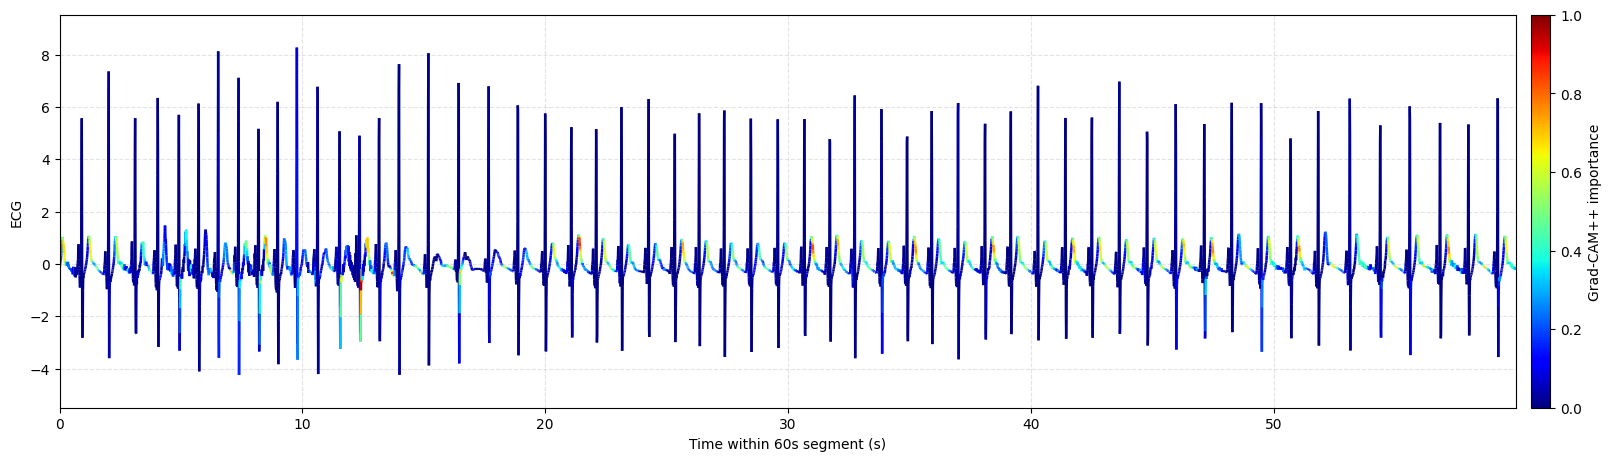

In [4]:
# TP-only Grad-CAM++ visualization (single true-positive segment)

def run_record_inference_and_cam_tp_only(
    record_name,
    data_path,
    exp11_path,
    weights_path,
    out_path,
):
    ns = load_exp11_symbols(exp11_path)
    preprocess_signal = ns["preprocess_signal"]
    segment_signal = ns["segment_signal"]
    CustomApneaModel = ns["CustomApneaModel"]

    device = pick_device()

    model = CustomApneaModel().to(device)
    ckpt = torch.load(weights_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"] if isinstance(ckpt, dict) and "model_state_dict" in ckpt else ckpt)
    model.eval()

    record = wfdb.rdrecord(str(data_path / record_name))
    ann = wfdb.rdann(str(data_path / record_name), "apn")

    fs = int(record.fs)
    raw_signal = record.p_signal[:, 0]
    labels = ann.symbol

    _, X_seg, y_true = build_record_segments(raw_signal, labels, fs, preprocess_signal, segment_signal)

    if len(X_seg) == 0:
        raise ValueError(f"No valid 60s segments for record {record_name}")

    target_layer = model.fuse.block[0]

    pred_probs = []
    pred_labels = []
    cams = []

    for i in range(len(X_seg)):
        x = torch.tensor(X_seg[i], dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
        with torch.no_grad():
            logits = model(x)
            probs = torch.softmax(logits, dim=1)[0]
            p_apnea = float(probs[1].item())
            y_hat = int(torch.argmax(probs).item())

        cam = gradcam_plus_plus_1d(model, x, target_layer=target_layer, class_idx=1)

        pred_probs.append(p_apnea)
        pred_labels.append(y_hat)
        cams.append(cam)

    pred_probs = np.array(pred_probs, dtype=np.float32)
    pred_labels = np.array(pred_labels, dtype=np.int64)
    y_true = np.array(y_true, dtype=np.int64)

    tp_mask = (pred_labels == 1) & (y_true == 1)
    tp_idx_all = np.where(tp_mask)[0]

    if len(tp_idx_all) == 0:
        raise ValueError(f"No true-positive segment found for record {record_name}")

    # Representative TP: the TP with highest apnea probability.
    tp_idx = int(tp_idx_all[np.argmax(pred_probs[tp_idx_all])])

    seg_signal = X_seg[tp_idx]
    seg_cam = cams[tp_idx]
    t_local = np.arange(len(seg_signal)) / float(fs)

    fig, ax = plt.subplots(1, 1, figsize=(16, 4.5), constrained_layout=True)

    pts = np.array([t_local, seg_signal]).T.reshape(-1, 1, 2)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
    norm = Normalize(vmin=0.0, vmax=1.0)
    lc = LineCollection(segs, cmap="jet", norm=norm)
    lc.set_array(seg_cam[:-1])
    lc.set_linewidth(1.8)
    ax.add_collection(lc)

    ax.set_xlim(t_local.min(), t_local.max())
    y_pad = 0.1 * (seg_signal.max() - seg_signal.min() + 1e-6)
    ax.set_ylim(seg_signal.min() - y_pad, seg_signal.max() + y_pad)
    ax.set_xlabel("Time within 60s segment (s)")
    ax.set_ylabel("ECG")
    
    ax.grid(True, ls="--", alpha=0.35)
    fig.colorbar(lc, ax=ax, pad=0.01, label="Grad-CAM++ importance")

    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    print(f"Saved TP-only figure: {out_path}")

    # Console summary
    print(f"Segments: {len(pred_labels)}")
    print(f"True positives found: {len(tp_idx_all)}")
    print(f"Selected TP minute index: {tp_idx}")


OUT_PATH_TP = Path("output") / f"gradcam_exp11_{record_name}_tp_only.png"

run_record_inference_and_cam_tp_only(
    record_name=record_name,
    data_path=DATA_PATH,
    exp11_path=EXP11_PATH,
    weights_path=WEIGHTS_PATH,
    out_path=OUT_PATH_TP,
)

